In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Делаем запрос к сайту
url = 'http://books.toscrape.com/'
response = requests.get(url)

# Проверяем, что сайт ответил успешно (код 200)
print(f"Статус ответа: {response.status_code}")

# 2. Превращаем HTML-код в объект BeautifulSoup для удобного поиска
soup = BeautifulSoup(response.text, 'html.parser')

# 3. Находим все блоки с книгами на странице (у них есть класс 'product_pod')
books = soup.find_all('article', class_='product_pod')

print(f"Найдено книг на странице: {len(books)}")

# 4. Извлекаем данные из первой книги, чтобы понять структуру
first_book = books[0]

# Название книги (находится внутри тега <h3> -> <a> в атрибуте title)
title = first_book.h3.a['title']

# Цена (находится в теге <p> с классом 'price_color')
price = first_book.find('p', class_='price_color').text

# Рейтинг (находится в теге <p> с классом, начинающимся на 'star-rating', например 'star-rating Three')
# Берем второй класс из списка классов (первый - 'star-rating', второй - сам рейтинг)
rating = first_book.find('p', class_='star-rating')['class'][1]

print(f"\nПример извлеченных данных:")
print(f"Название: {title}")
print(f"Цена: {price}")
print(f"Рейтинг: {rating}")

Статус ответа: 200
Найдено книг на странице: 20

Пример извлеченных данных:
Название: A Light in the Attic
Цена: Â£51.77
Рейтинг: Three


In [3]:
print(f"Тип response.text: {type(response.text)}") # Это просто строка (str)
print(f"Длина строки: {len(response.text)} символов\n")

print(f"Тип soup: {type(soup)}") # Это сложный объект BeautifulSoup
print(f"Заголовок страницы из soup: {soup.title.text}")

Тип response.text: <class 'str'>
Длина строки: 51294 символов

Тип soup: <class 'bs4.BeautifulSoup'>
Заголовок страницы из soup: 
    All products | Books to Scrape - Sandbox



In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time # Важно для "вежливого" парсинга

# Создаем пустые списки для хранения данных
titles = []
prices = []
ratings = []
availabilities = []

# Будем парсить первые 5 страниц
for page_num in range(1, 6):
    print(f"Парсим страницу {page_num}...")

    # Формируем URL для каждой страницы
    if page_num == 1:
        url = 'http://books.toscrape.com/'
    else:
        url = f'http://books.toscrape.com/catalogue/page-{page_num}.html'

    # Делаем запрос
    response = requests.get(url)
    #response.encoding = 'utf-8' # <-- Говорим Python: "Читай это как UTF-8"
    # Если страница загрузилась успешно
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        books = soup.find_all('article', class_='product_pod')

        # Проходимся по каждой книге на странице
        for book in books:
            # Название
            title = book.h3.a['title']
            titles.append(title)

            # Цена (убираем символ фунта '£')
            price_text = book.find('p', class_='price_color').text
            prices.append(price_text.replace('£', ''))

            # Рейтинг (берем второй класс, например 'Three' из ['star-rating', 'Three'])
            rating = book.find('p', class_='star-rating')['class'][1]
            ratings.append(rating)

            # Наличие на складе (например, 'In stock')
            availability = book.find('p', class_='instock availability').text.strip()
            availabilities.append(availability)

    # Делаем паузу 1 секунду, чтобы не "положить" сайт частыми запросами (best practice!)
    time.sleep(1)

# Создаем итоговый DataFrame
df_books = pd.DataFrame({
    'title': titles,
    'price': prices,
    'rating': ratings,
    'availability': availabilities
})

print(f"\n✅ Готово! Собрано {len(df_books)} книг.")
display(df_books.head(10))
print("\nИнформация о типах данных:")
print(df_books.info())

Парсим страницу 1...
Парсим страницу 2...
Парсим страницу 3...
Парсим страницу 4...
Парсим страницу 5...

✅ Готово! Собрано 100 книг.


,title,price,rating,availability
0,A Light in the Attic,Â51.77,Three,In stock
1,Tipping the Velvet,Â53.74,One,In stock
2,Soumission,Â50.10,One,In stock
3,Sharp Objects,Â47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â54.23,Five,In stock
5,The Requiem Red,Â22.65,One,In stock
6,The Dirty Little Secrets of Getting Your Dream...,Â33.34,Four,In stock
7,The Coming Woman: A Novel Based on the Life of...,Â17.93,Three,In stock
8,The Boys in the Boat: Nine Americans and Their...,Â22.60,Four,In stock
9,The Black Maria,Â52.15,One,In stock



Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         100 non-null    object
 1   price         100 non-null    object
 2   rating        100 non-null    object
 3   availability  100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB
None


In [5]:
# Удаляем символ £ и превращаем в float
df_books['price'] = df_books['price'].str.replace('Â', '').astype(float)

print("Цена после очистки:")
display(df_books[['title', 'price']].head())
print(f"\nТип данных: {df_books['price'].dtype}")  # Должно быть float64

Цена после очистки:


,title,price
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23



Тип данных: float64


In [6]:
display(df_books.head(10))

,title,price,rating,availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock
5,The Requiem Red,22.65,One,In stock
6,The Dirty Little Secrets of Getting Your Dream...,33.34,Four,In stock
7,The Coming Woman: A Novel Based on the Life of...,17.93,Three,In stock
8,The Boys in the Boat: Nine Americans and Their...,22.60,Four,In stock
9,The Black Maria,52.15,One,In stock


In [7]:
# Создаем словарь для преобразования
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

# Применяем маппинг к колонке
df_books['rating'] = df_books['rating'].map(rating_map)

print("Рейтинг после очистки:")
display(df_books[['title', 'rating']].head())
print(f"\nТип данных: {df_books['rating'].dtype}")  # Должно быть int64

Рейтинг после очистки:


,title,rating
0,A Light in the Attic,3
1,Tipping the Velvet,1
2,Soumission,1
3,Sharp Objects,4
4,Sapiens: A Brief History of Humankind,5



Тип данных: int64


In [8]:
print("Информация о датафрейме после очистки:")
df_books.info()

Информация о датафрейме после очистки:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         100 non-null    object 
 1   price         100 non-null    float64
 2   rating        100 non-null    int64  
 3   availability  100 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ KB


Средняя цена по рейтингам:


,rating,price
0,1,35.519545
1,2,35.909474
2,3,36.839091
3,4,33.981667
4,5,30.012105


/tmp/ipykernel_3524/2106934991.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='price', data=df_books, palette='mako', errorbar=None)


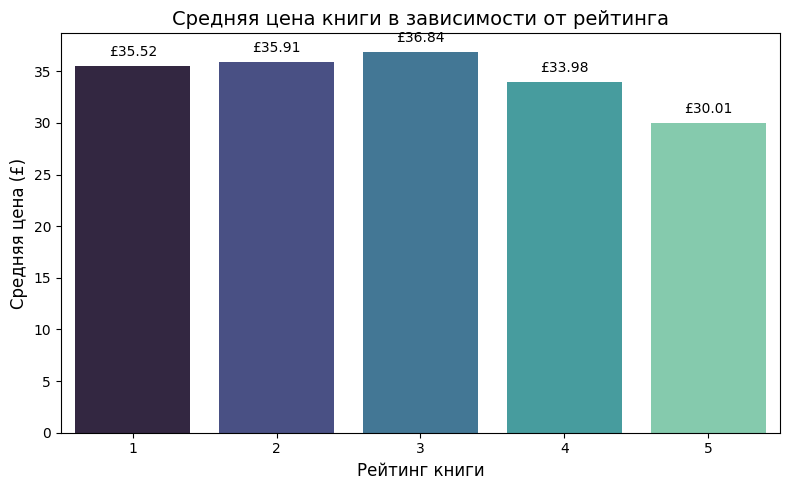

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем среднюю цену для каждого рейтинга
avg_price_by_rating = df_books.groupby('rating')['price'].mean().reset_index()

print("Средняя цена по рейтингам:")
display(avg_price_by_rating)

# 2. Строим график
plt.figure(figsize=(8, 5))
sns.barplot(x='rating', y='price', data=df_books, palette='mako', errorbar=None)

plt.title('Средняя цена книги в зависимости от рейтинга', fontsize=14)
plt.xlabel('Рейтинг книги', fontsize=12)
plt.ylabel('Средняя цена (£)', fontsize=12)

# Добавляем значения на столбцы
for i, row in avg_price_by_rating.iterrows():
    plt.text(i, row['price'] + 1, f"£{row['price']:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('price_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()